## 1.1 Import những module và thư viện cần thiết

In [6]:
import re
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import underthesea
import os

## 1.2. Read the dataset from file path


In [2]:
df = pd.read_csv(r"Data/raw/labeled_data.csv")

## 2. EDA

In [3]:
df.head()

,comment,label
0,Shop phục vụ rất kém,NEG
1,"Tôi về vất đi rồi, chỉ đc quảng cáo hay thôi, ...",NEG
2,Chất lượng sản phẩm rất kém Đóng gói sản phẩm ...,NEG
3,Bề ngang áo chật,NEG
4,Và hẳn đây là tai mèo,NEG


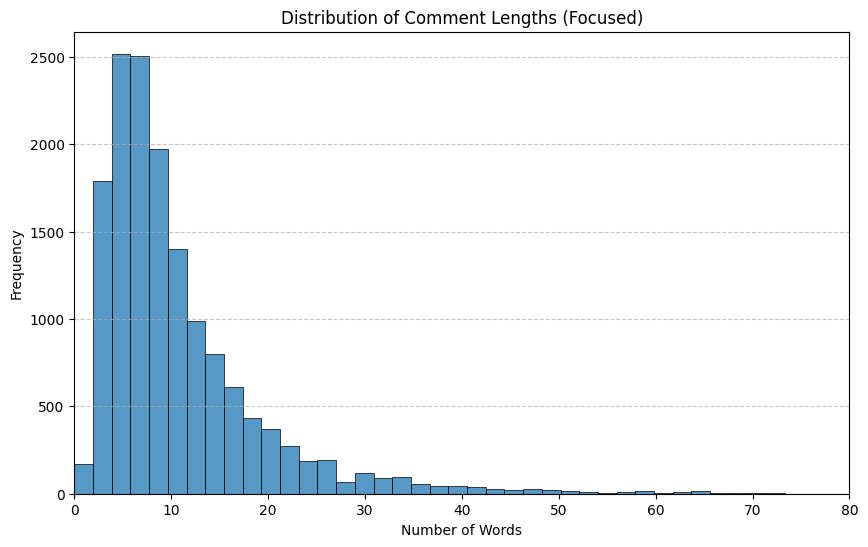

In [4]:
df['comment_length'] = df['comment'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)


plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=100) #
plt.title('Distribution of Comment Lengths (Focused)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')


plt.xlim(0, 80)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

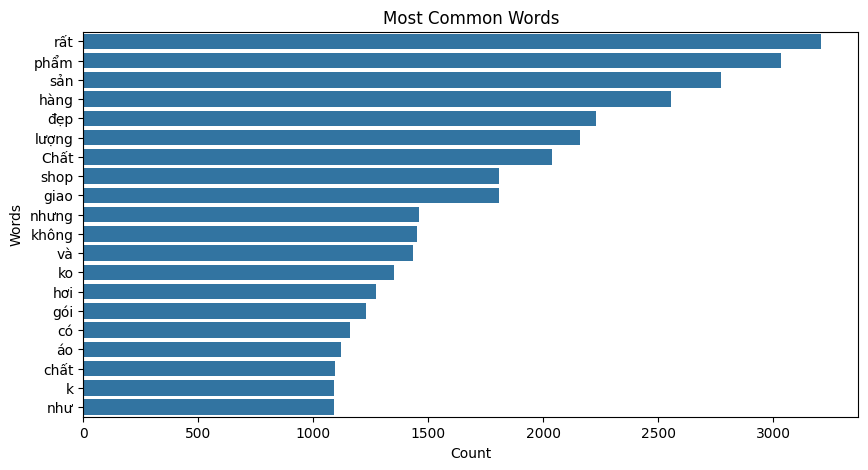

In [7]:
all_comments = ' '.join(df['comment'].astype(str))

# Tách từ và đếm tần suất xuất hiện
words = all_comments.split()
word_counts = Counter(words)

# Lấy 20 từ phổ biến nhất
common_words = word_counts.most_common(20)
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])


plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=common_words_df)
plt.title('Most Common Words')
plt.xlabel('Count')
plt.ylabel('Words')
plt.show()